### TODOS
- Do analysis short vs. long sequences
- Length comparison how well does whisper legnth correlate with real length
- Are short sequences more often wrong than long sequences?
- F1 at predicting short sequences vs long sequences
- LLM with context
- fix space and casing issue


### TODOs (Suryansh)
2. Stop word analysis for GT and generated

In [8]:
import pandas as pd
import os
from tqdm.auto import tqdm
from llm_asr_clarification.constants import SAMPLE_MEETINGS
import json
import torch
import torch.nn.functional as F
from rouge_score import rouge_scorer
from transformers import AutoTokenizer
from jiwer import wer
import jiwer

# Define a robust transformation pipeline
# This applies data cleaning steps in order, from top to bottom
JIWER_TRANSFORM = jiwer.Compose([
    jiwer.ToLowerCase(),                # Convert all text to lowercase
    jiwer.RemovePunctuation(),          # Strip characters like commas, periods, question marks
    jiwer.RemoveMultipleSpaces(),       # Turn multi-spaces into a single space
    jiwer.Strip(),                      # Clean up leading/trailing whitespaces
    jiwer.ReduceToListOfListOfWords()   # Format text tokens perfectly for jiwer's internal engine
])


pd.set_option('display.max_colwidth', None)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   # or another causal LM
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    # use_stemmer=True,
    use_stemmer=False
)

def rouge_l(pred, ref):
    return scorer.score(
        ref,   # reference first
        pred   # prediction second
    )["rougeL"]

def load_df_from_path(AMI_PATH):
    meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
        
    data = []
    for meeting_path in tqdm(meeting_paths):
        beam_results = os.path.join(meeting_path, "artifacts", "beam_results.json")
        try:
            with open(beam_results, "r", encoding="utf-8") as f:
                lines = f.read()
            lines = json.loads(lines)
        except Exception as err:
            print(f"couldnt open file {beam_results}")
            continue
    
        # Process lines
        for line in lines:
            for i in range(1,6):
                beam_no = f'beam_{i}'
                beam = line.pop(beam_no)
    
                line[f"{beam_no}_text"] = beam["text"]
                line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
                line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
            line["meeting_name"] = meeting_path.split("/")[-1]

            data.append(line)
            
    # df = pd.DataFrame(lines)
    df = pd.DataFrame(data)
    return df
    
AMI_TRAIN_PATH = '/group/jrwhitehill/amicorpus/train'
AMI_VAL_PATH = '/group/jrwhitehill/amicorpus/validation'

df = load_df_from_path(AMI_TRAIN_PATH)
df_val = load_df_from_path(AMI_VAL_PATH)

  0%|          | 0/136 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

In [9]:
print(df.shape)
print(df_val.shape)

(88717, 17)
(10590, 17)


In [10]:
df.head(3)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,beam_4_text,beam_4_asrlogprob,beam_4_llmlogprob,beam_5_text,beam_5_asrlogprob,beam_5_llmlogprob,meeting_name
0,Okay.,Okay.,-0.165992,-10.1875,Okay.,-0.165992,-10.18750,Okay.,-0.165992,-10.1875,OK.,-0.808041,-11.0000,Okay.,-0.165992,-10.1875,ES2005d
1,"Okay, almost there.",Okay.,-0.202354,-10.1875,Okay. I want to say.,-0.761428,-5.21875,Okay.,-0.202354,-10.1875,Okay.,-0.202354,-10.1875,Okay. I was there.,-0.371616,-5.5000,ES2005d
2,Okay.,Okay,-0.634828,-17.0000,Ok,-2.403044,-19.62500,Okay.,-0.134573,-10.1875,OK.,-0.716196,-11.0000,Okay.,-0.134573,-10.1875,ES2005d


In [11]:
import re
import string

def normalize_text(text: str) -> str:
    """Mirrors the jiwer text normalization pipeline, except for last stage"""
    if not text:
        return ""
    
    # 1. jiwer.ToLowerCase()
    text = text.lower()
    
    # 2. jiwer.RemovePunctuation()
    # Removes standard punctuation: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. jiwer.RemoveMultipleSpaces()
    text = re.sub(r'\s+', ' ', text)
    
    # 4. jiwer.Strip()
    text = text.strip()
    
    return text

In [12]:
def process_columns(df):
    llm_logprob_columns = [f'beam_{i}_llmlogprob' for i in range(1,6)]
    asr_logprob_columns = [f'beam_{i}_asrlogprob' for i in range(1,6)]
    
    llm_logprobs = torch.tensor(df[llm_logprob_columns].values)
    asr_logprobs = torch.tensor(df[asr_logprob_columns].values)
    
    # # ALL BEAMS
    # scores = F.softmax(ALPHA*llm_logprobs + 0.0asr_logprobs, dim=1)
    # highest_score_idxs = torch.argmax(scores, dim=1, keepdim=True)
    # highest_scores = torch.gather(scores, dim=1, index=highest_score_idxs)

    # JUST BEAM 1
    scores = llm_logprobs
    highest_scores = scores[torch.arange(scores.size(0)), torch.zeros(scores.size(0), dtype=torch.long)]


    # AGGREGATED STATS
    df['max_llmlogprobs'] = torch.max(llm_logprobs, dim=1).values.numpy()
    df['min_llmlogprobs'] = torch.min(llm_logprobs, dim=1).values.numpy()
    df['spread_llmlogprobs'] = df['max_llmlogprobs'] - df['min_llmlogprobs']

    df['max_asrlogprobs'] = torch.max(asr_logprobs, dim=1).values.numpy()
    df['min_asrlogprobs'] = torch.min(asr_logprobs, dim=1).values.numpy()
    df['spread_asrlogprobs'] = df['max_asrlogprobs'] - df['min_asrlogprobs']

    df['highest_score'] = highest_scores.numpy()
    
    df['text'] = df['beam_1_text']
    df['num_tokens_text'] = df['beam_1_text'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    df['num_tokens_gt'] = df['gt'].apply(
        lambda x: len(tokenizer.encode(x))
    )
    
    
    df["rougeL"] = [
        rouge_l(normalize_text(pred), normalize_text(ref)).fmeasure
        for pred, ref in zip(df["text"], df["gt"])
    ]
    df["wer"] = [
        min(1.0, wer(reference = ref, hypothesis = pred, reference_transform = JIWER_TRANSFORM, hypothesis_transform = JIWER_TRANSFORM))
        for pred, ref in zip(df["text"], df["gt"])
    ]

process_columns(df)
process_columns(df_val)

In [13]:
df.head(5)

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,...,spread_llmlogprobs,max_asrlogprobs,min_asrlogprobs,spread_asrlogprobs,highest_score,text,num_tokens_text,num_tokens_gt,rougeL,wer
0,Okay.,Okay.,-0.165992,-10.18750,Okay.,-0.165992,-10.18750,Okay.,-0.165992,-10.18750,...,0.81250,-0.165992,-0.808041,0.642049,-10.18750,Okay.,3,3,1.000000,0.000000
1,"Okay, almost there.",Okay.,-0.202354,-10.18750,Okay. I want to say.,-0.761428,-5.21875,Okay.,-0.202354,-10.18750,...,4.96875,-0.202354,-0.761428,0.559074,-10.18750,Okay.,3,6,0.500000,0.666667
2,Okay.,Okay,-0.634828,-17.00000,Ok,-2.403044,-19.62500,Okay.,-0.134573,-10.18750,...,9.43750,-0.134573,-2.403044,2.268470,-17.00000,Okay,2,3,1.000000,0.000000
3,"We'll sta I'll use the PowerPoint, I guess.","Oh well, I'll use the PowerPoint, I guess.",-0.256419,-4.90625,"well, I'll use the powerpoint I guess.",-0.460730,-6.03125,"Well, I'll use the PowerPoint, I guess.",-0.103038,-5.28125,...,2.43750,-0.103038,-0.460730,0.357692,-4.90625,"Oh well, I'll use the PowerPoint, I guess.",13,13,0.875000,0.250000
4,"How was that, was that fun?","How was that, was that?",-0.126335,-6.53125,"I was that, was that.",-0.454225,-8.18750,I was that was enough.,-0.371302,-9.18750,...,2.65625,-0.126335,-0.454225,0.327890,-6.53125,"How was that, was that?",8,9,0.909091,0.166667


# whisper text len vs. ground truth text len

In [14]:
import matplotlib.pyplot as plt

def corr_analysis(df, x='highest_score', y='rougeL'):
    df.plot.scatter(x=x, y=y)
    
    # Display the plot
    plt.show()
    
    from scipy.stats import pearsonr
    
    result = pearsonr(df[x], df[y])
    
    print(f"Pearson r: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")

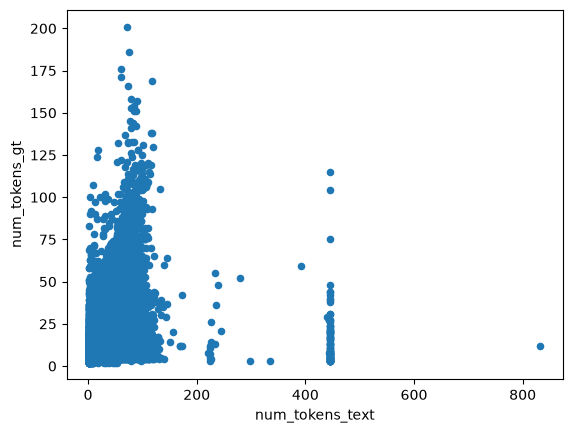

Pearson r: 0.5448
P-value: 0.0000


In [15]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

In [18]:
# Filter out seqs with tokens greater than or equal to 400 in the generated text
df = df[df['num_tokens_text'] < 400]
df_val = df_val[df_val['num_tokens_text'] < 400]

short_idx = df['num_tokens_text'] <= 5

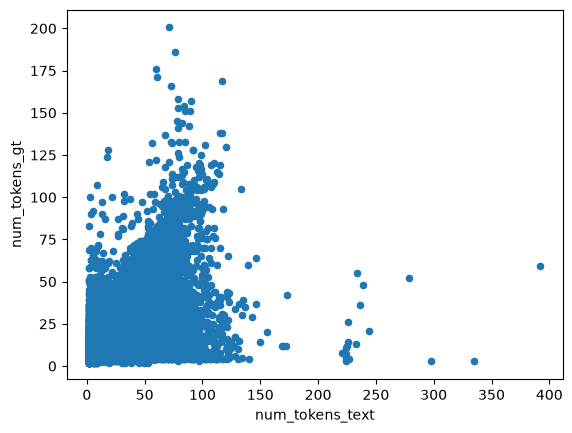

Pearson r: 0.7294
P-value: 0.0000


In [20]:
corr_analysis(df,'num_tokens_text','num_tokens_gt')

<Axes: >

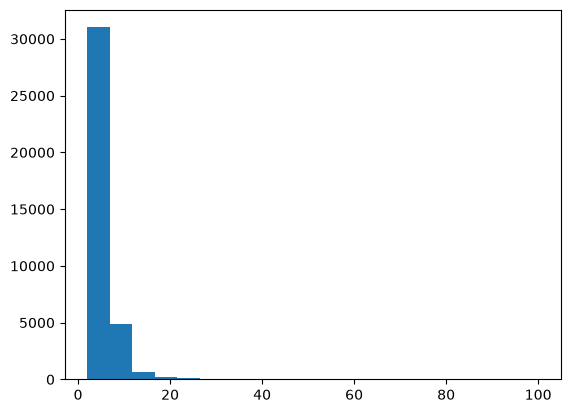

In [21]:
df[short_idx]['num_tokens_gt'].hist(bins=20, grid=False)

In [22]:
# Number of short sequences
sum(short_idx)

37016

In [23]:
# Get the number of times GT sequences were longer than generated
sum((df['num_tokens_gt'] > df['num_tokens_text']))

54926

In [24]:
# Num of times GT sequences are longer than generated short seqs
sum((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))

28401

In [25]:
# % of GT seqs longer than generated short seqs 
len(df[((df['num_tokens_gt'] > df['num_tokens_text']) & (short_idx))])/len(df[short_idx])

0.7672628052733953

In [26]:
# % of when long seqs had short transcriptions (mostly mistranscriptions)
len(df[((df['num_tokens_gt'] > 5) & (short_idx))])/len(df[short_idx])

0.2917387075859088

In [27]:
# Sample 10 generated short seqs and their equivalent GT
df[short_idx][['text','gt']].sample(10)

,text,gt
68495,yeah.,Yeah.
61414,I like it,I like that it stands up.
22225,So you were doing,We were doing yeah.
34529,fun. Yeah.,Mm.
71821,I,Okay.
78723,Um...,Um.
87188,the current things.,"Spongy is the current texture, but basically there are no reports no remotes at the moment which are spongy or tactile at all, so if we make it like maybe furry or soft or something, that'll be something that sets it apart, rather than just bare plastic which they all are at the moment."
25669,Yeah.,Yeah.
10809,60,"Oh, okay, indeed."
33239,You,Yeah.


# errors analysis

In [28]:
df['wer'].describe()

count    88630.000000
mean         0.715794
std          0.342662
min          0.000000
25%          0.408163
50%          1.000000
75%          1.000000
max          1.000000
Name: wer, dtype: float64

In [29]:
df[['text','gt','wer','rougeL']].sample(5)

,text,gt,wer,rougeL
45893,Thanks,Me Ah yeah.,1.000000,0.000000
83806,you,Yeah.,1.000000,0.000000
69232,And we will be able to process some conversation just to see what happens and to have this models on feedback working when people are using the term.,And uh we will be able to process to post-process some conversation just to see what happens and to uh have these um models on feedback working when people are using the table.,0.212121,0.852459
4979,"So what about foreign words? What do we do when we're checking if we come up something? Alright, so we just let it pass. The transcribers enclosing everything in carrots.","So um about um foreign words, what do we when we're checking um if we come up something so we just leave it as Yeah.",0.520000,0.690909
82901,channels.,Yes.,1.000000,0.000000


In [30]:
# Define 0.5 as threshold, this is finding what % of transcriptions were wrong based on ROUGE L
sum(df['rougeL'] < 0.5)/len(df)

0.5922148256797924

In [31]:
# Define 0.5 as threshold, this is finding what % of transcriptions were wrong based on WER
sum(df['wer'] > 0.5)/len(df)

0.6747828049193275

In [32]:
# Recaluculate short indices
short_idx = df['num_tokens_text'] <= 5

In [33]:
# Get indices of mistranscribed seqs based on ROUGE L and WER
errors_rougeL_idx = df['rougeL'] < 0.5
errors_wer_idx = df['wer'] > 0.5

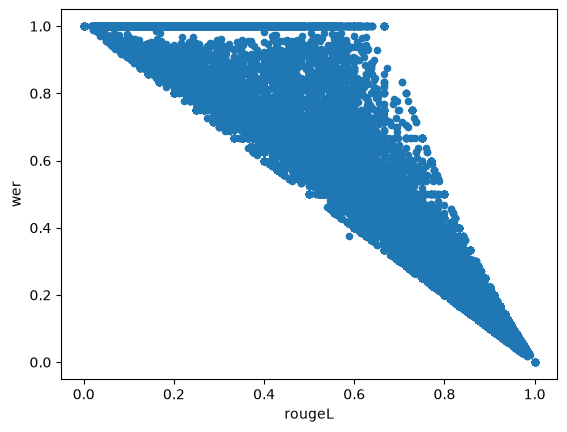

Pearson r: -0.9491
P-value: 0.0000


In [34]:
corr_analysis(df,'rougeL','wer')

<Axes: >

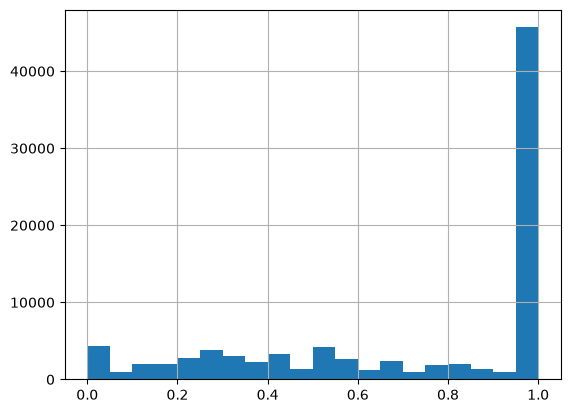

In [35]:
# Generate hist distr of WER
df['wer'].hist(bins=20)

In [36]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
67181,Thank you.,Right.,0.000000,1.000
8980,the,For a big team of artists.,0.000000,1.000
35729,You know.,Mm-hmm.,0.000000,1.000
15226,you,Yeah.,0.000000,1.000
63750,Before coming from a small ski moment.,"Before come up with the scheme, you mean.",0.133333,0.875
77503,It would be like that.,"It would be even more oh, you really like titanium.",0.533333,0.600
56219,you,Alright.,0.000000,1.000
55485,We won't have it again.,We're gonna have a beep.,0.200000,0.800
28087,you,Yeah.,0.000000,1.000
34216,that,That might just So.,0.400000,0.750


In [37]:
# Look at mistranscriptions according to ROUGEL
df[errors_rougeL_idx][['text','gt','rougeL', 'wer']].sample(10)

,text,gt,rougeL,wer
55822,Focusing her?,Nice.,0.000000,1.000000
75344,for my,Um I'm from India.,0.000000,1.000000
14943,had. So if we wanted to make a big air so it's so,"So even if we wanted to make a bigger prototype, we wouldn't have been able to.",0.482759,0.625000
73065,you,Mm-hmm.,0.000000,1.000000
32076,"Right, so that's one","So that's what CELP is doing, right.",0.363636,0.857143
45824,This still I guess.,Just sit still I guess for a little while.,0.461538,0.666667
88494,Thank you.,Yeah.,0.000000,1.000000
48665,to this before.,No.,0.000000,1.000000
38499,So,Okay.,0.000000,1.000000
81237,"I think we've done an amazing job in. Well done us. So I want 2, 2, 4, 5, 6, 7, 8, 9, 10, 11. 11 divided by 11. 11's 1. Of course average of 1 need a cover.",So uh I I think we've done an amazing job in uh coming up with what Need a need a calculator for that.,0.327869,1.000000


In [38]:
# Look at mistranscriptions according to WER
df[errors_wer_idx][['text','gt']].sample(10)

,text,gt
54706,So then we're not gonna make it.,"So, then uh then then then then then then Then Uh, no."
88125,you,Exactly.
80283,here. You're the boss you're allowed to. Well the one man to design you also have an improvement of the size because you know from self-believe they can be too smart.,Uh um Yeah.
25302,"Now, to take","No, I don't think so."
28911,and,Um.
69856,Let's see the味.,Excuse me?
38545,So much.,True.
9603,industrial design. Yeah.,"That's industrial design for cranes, stuff like that."
43870,"This is a random time, this a random time.","No, but this is disadvant disadvantage."
22305,I'm sorry.,They shouldn't be in there.


In [40]:
print(df['rougeL'].describe())
rougeL_fifty = df['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")
rougeL_twentyfive = df['rougeL'].quantile(0.25)
print(f"25th quartile for rougeL is: {rougeL_twentyfive:.2f}")

count    88630.000000
mean         0.358234
std          0.362514
min          0.000000
25%          0.000000
50%          0.285714
75%          0.700000
max          1.000000
Name: rougeL, dtype: float64
50th quartile for rougeL is: 0.29
25th quartile for rougeL is: 0.00


In [41]:
errors_idx = errors_rougeL_idx

In [42]:
p_error = len(df[errors_idx])/len(df)
print(f"P(error) = {p_error:.3f}")
p_short = len(df[short_idx])/len(df)
print(f"P(short) = {p_short:.3f}")

p_error_given_short = len(df[(short_idx) & (errors_idx)]) / len(df[short_idx])
print(f"P(error|short) = {p_error_given_short:.3f}")

p_error_given_long = len(df[(~short_idx) & (errors_idx)]) / len(df[~short_idx])
print(f"P(error|long) = {p_error_given_long:.3f}")

p_short_given_error = len(df[(short_idx) & (errors_idx)]) / len(df[errors_idx])
print(f"P(short|error) = {p_short_given_error:.3f}")
print(f"P(long|error) = {1-p_short_given_error:.3f}")

P(error) = 0.592
P(short) = 0.418
P(error|short) = 0.844
P(error|long) = 0.412
P(short|error) = 0.595
P(long|error) = 0.405


In [43]:
from statsmodels.stats.proportion import proportions_ztest

# Number of errors in each group
n_errors_short = ((short_idx) & (errors_idx)).sum()
n_errors_long = ((~short_idx) & (errors_idx)).sum()

# Number of samples in each group
n_short = short_idx.sum()
n_long = (~short_idx).sum()

# Two-proportion z-test
count = [n_errors_short, n_errors_long]
nobs = [n_short, n_long]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Short error rate: {n_errors_short/n_short:.3f}")
print(f"Long error rate:  {n_errors_long/n_long:.3f}")
print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.6f}")

Short error rate: 0.844
Long error rate:  0.412
z = 129.070
p = 0.000000


# filtering for actual long utterances

<Axes: >

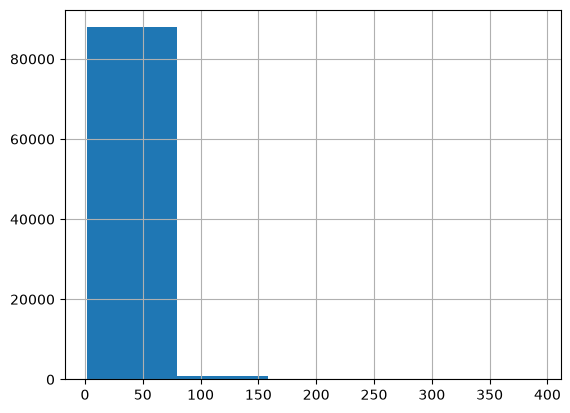

In [44]:
df['num_tokens_text'].hist(bins=5)

In [45]:
# Filter out for only actual phrases not just 'ummm' and 'ahhh' and 'yeahh'
longs_df = df[~short_idx]
shorts_df = df[short_idx]

In [46]:
# min_score = min(df['highest_score'])
# range_score = max(df['highest_score']) - min_score
# df['normalized_score'] = (df['highest_score'] - min_score)/range_score

# def standardize_df(datfram):
#     datfram['normalized_score'] = (
#         datfram['highest_score'] - datfram['highest_score'].mean()
#     )/datfram['highest_score'].std()

# standardize_df(df)
# standardize_df(shorts_df)
# standardize_df(longs_df)

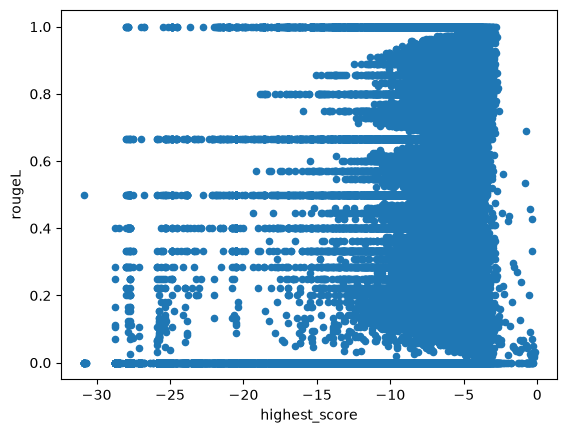

Pearson r: 0.5445
P-value: 0.0000


In [47]:
corr_analysis(df)

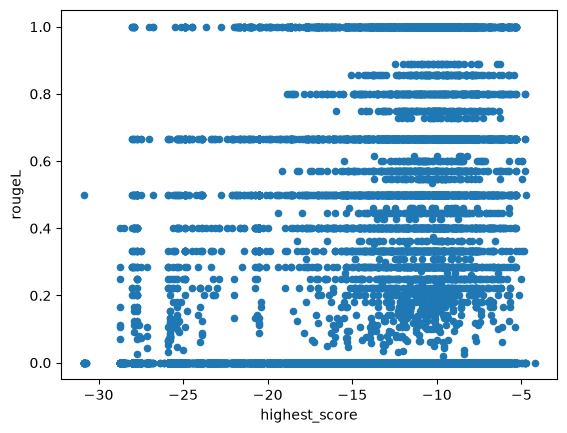

Pearson r: 0.3715
P-value: 0.0000


In [48]:
corr_analysis(shorts_df)

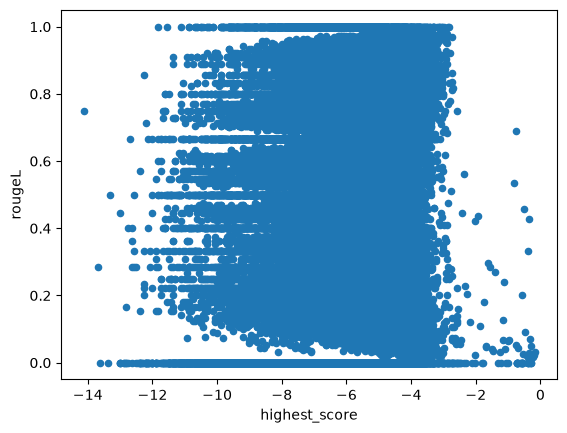

Pearson r: 0.2453
P-value: 0.0000


In [49]:
corr_analysis(longs_df)

<Axes: >

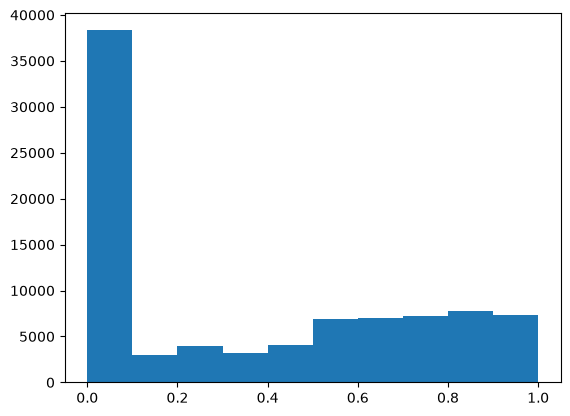

In [50]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

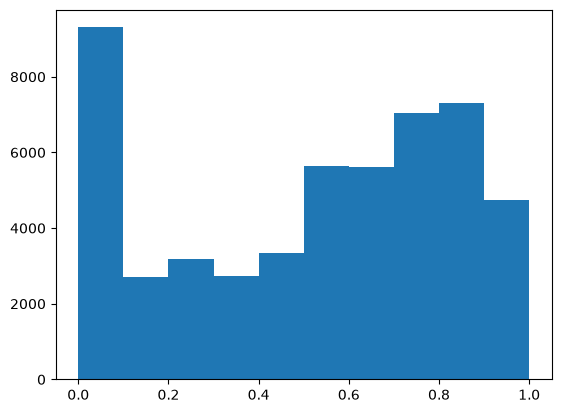

In [51]:
longs_df['rougeL'].hist(grid=False, bins=10)

<Axes: >

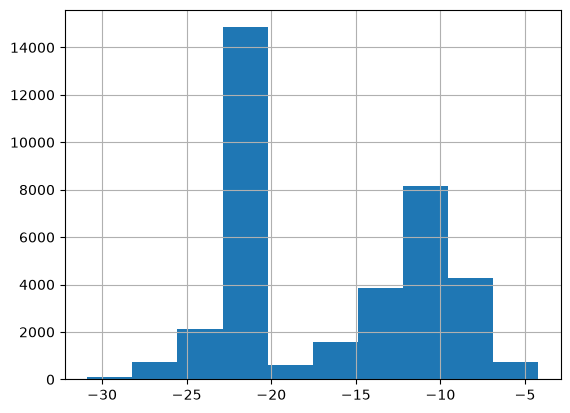

In [52]:
shorts_df['highest_score'].hist()

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["highest_score", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["highest_score"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []

    roc_auc = roc_auc_score(y_true, -df["highest_score"])
    
    for thresh in thresholds:
        y_pred = (
            (df["highest_score"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"ROCAUC: {roc_auc}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [54]:
pd.set_option('display.max_colwidth', None)

Best threshold: -6.0024
ROCAUC: 0.7780192795474025
Best F1: 0.7633
Precision at best F1: 0.7018
Recall at best F1: 0.8366



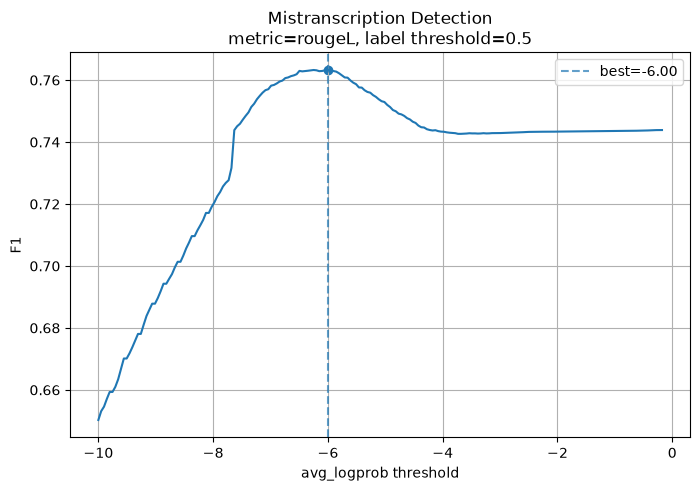

In [55]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -0.1787
ROCAUC: 0.6122547706434984
Best F1: 0.5833
Precision at best F1: 0.4118
Recall at best F1: 1.0000



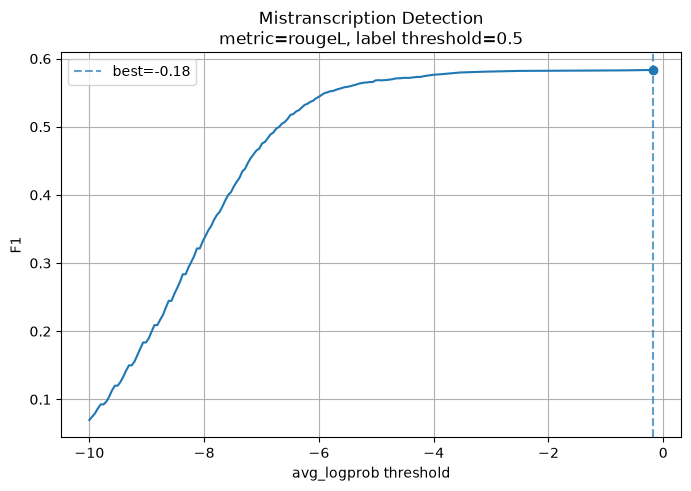

In [56]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: -7.6310
ROCAUC: 0.805810761232689
Best F1: 0.7439
Precision at best F1: 0.7265
Recall at best F1: 0.7622



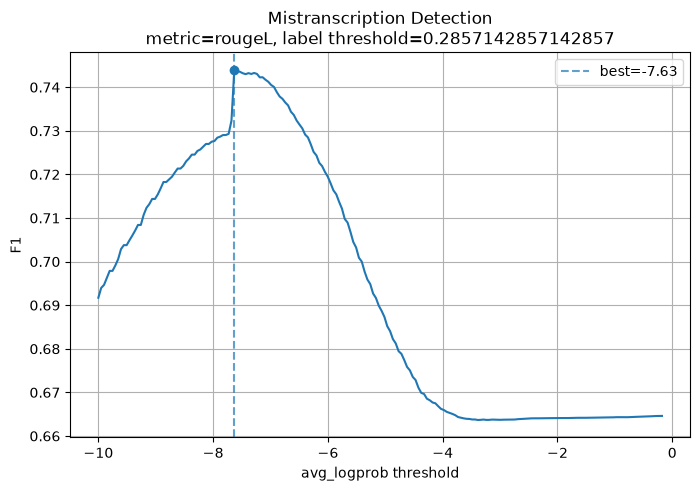

In [57]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

Best threshold: -5.8543
ROCAUC: 0.598747238894001
Best F1: 0.4376
Precision at best F1: 0.3324
Recall at best F1: 0.6401



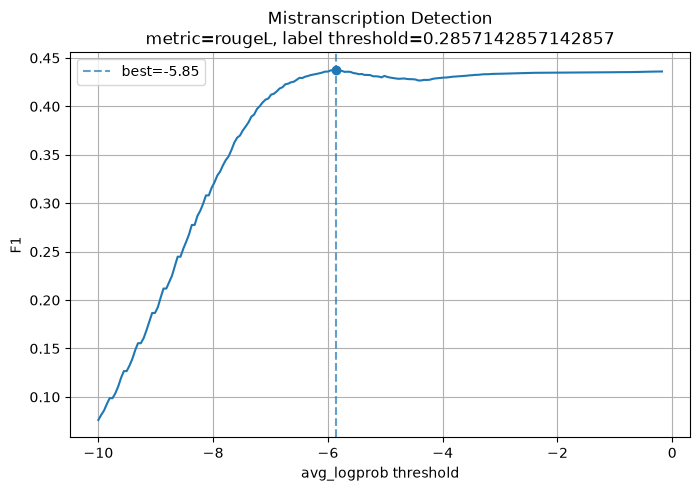

In [58]:
elbow_plot(longs_df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

# ml stuff

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df['y_true'] = errors_idx
df_val['y_true'] = df_val['rougeL'] < 0.5

FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
]

def train_and_eval_rf(FEATURES):
    TARGET = "y_true"
    
    # --------------------
    # Train RF
    # --------------------
    
    X_train = df[FEATURES]
    y_train = df[TARGET].astype(int)
    
    X_val = df_val[FEATURES]
    y_val = df_val[TARGET].astype(int)
    
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=30,
        random_state=42,
        n_jobs=-1,
    )
    
    rf.fit(X_train, y_train)
    
    # --------------------
    # Predictions
    # --------------------
    
    train_probs = rf.predict_proba(X_train)[:, 1]
    val_probs = rf.predict_proba(X_val)[:, 1]
    
    # --------------------
    # Overall AUROC
    # --------------------
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(f"Train AUROC: {train_auc:.4f}")
    print(f"Val   AUROC: {val_auc:.4f}")
    
    # --------------------
    # Short / Long subsets
    # --------------------
    
    train_shorts_idx = df["num_tokens_text"] <= 5
    val_shorts_idx = df_val["num_tokens_text"] <= 5
    
    def subset_auc(y, probs, mask):
        if y[mask].nunique() < 2:
            return float("nan")
        return roc_auc_score(y[mask], probs[mask])
    
    print("\nTRAIN")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_train, train_probs, train_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_train, train_probs, ~train_shorts_idx):.4f}"
    )
    
    print("\nVALIDATION")
    print(
        f"Short AUROC: "
        f"{subset_auc(y_val, val_probs, val_shorts_idx):.4f}"
    )
    print(
        f"Long  AUROC: "
        f"{subset_auc(y_val, val_probs, ~val_shorts_idx):.4f}"
    )


    def elbow_plot(
        y_true,
        scores,
        threshold_range=None,
        n_thresholds=200,
    ):
        """
        Finds the threshold maximizing F1.
    
        Parameters
        ----------
        y_true : array-like of bool/int
            Ground truth labels (1 = error).
    
        scores : array-like
            Probability or score where LARGER means MORE likely to be an error.
    
        threshold_range : (min, max) or None
            Threshold search range. Defaults to score min/max.
    
        Returns
        -------
        best_threshold, best_f1, best_precision, best_recall
        """
    
        y_true = np.asarray(y_true).astype(int)
        scores = np.asarray(scores)
    
        if threshold_range is None:
            tmin = scores.min()
            tmax = scores.max()
        else:
            tmin, tmax = threshold_range
    
        thresholds = np.linspace(tmin, tmax, n_thresholds)
    
        f1s = []
        precisions = []
        recalls = []
    
        for t in thresholds:
            pred = scores >= t
    
            precisions.append(
                precision_score(y_true, pred, zero_division=0)
            )
            recalls.append(
                recall_score(y_true, pred, zero_division=0)
            )
            f1s.append(
                f1_score(y_true, pred, zero_division=0)
            )
    
        f1s = np.array(f1s)
        precisions = np.array(precisions)
        recalls = np.array(recalls)
    
        best_idx = np.argmax(f1s)
    
        best_threshold = thresholds[best_idx]
        best_f1 = f1s[best_idx]
        best_precision = precisions[best_idx]
        best_recall = recalls[best_idx]
    
        plt.figure(figsize=(7,4))
        plt.plot(thresholds, f1s, label="F1")
        plt.plot(thresholds, precisions, label="Precision")
        plt.plot(thresholds, recalls, label="Recall")
    
        plt.axvline(
            best_threshold,
            linestyle="--",
            label=f"Best threshold = {best_threshold:.3f}",
        )
    
        plt.xlabel("Threshold")
        plt.ylabel("Metric")
        plt.title("Threshold selection")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Best F1:        {best_f1:.4f}")
        print(f"Precision:      {best_precision:.4f}")
        print(f"Recall:         {best_recall:.4f}")

    val_probs = rf.predict_proba(X_val)[:, 1]
    elbow_plot(y_val[~val_shorts_idx], val_probs[~val_shorts_idx])

    return rf

Train AUROC: 0.8347
Val   AUROC: 0.8072

TRAIN
Short AUROC: 0.8587
Long  AUROC: 0.7183

VALIDATION
Short AUROC: 0.8360
Long  AUROC: 0.6770


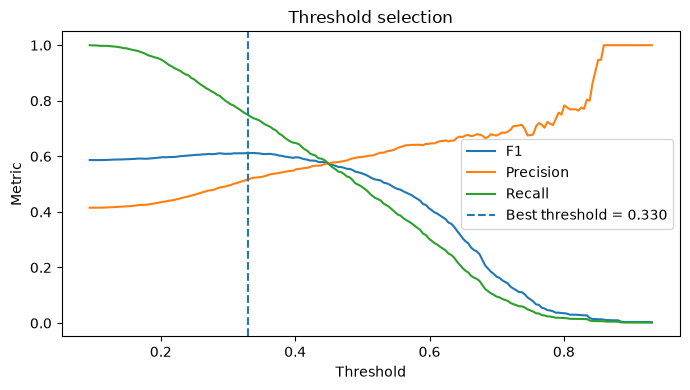

Best threshold: 0.3297
Best F1:        0.6122
Precision:      0.5173
Recall:         0.7497


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [60]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.8883
Val   AUROC: 0.8617

TRAIN
Short AUROC: 0.8852
Long  AUROC: 0.8301

VALIDATION
Short AUROC: 0.8620
Long  AUROC: 0.7920


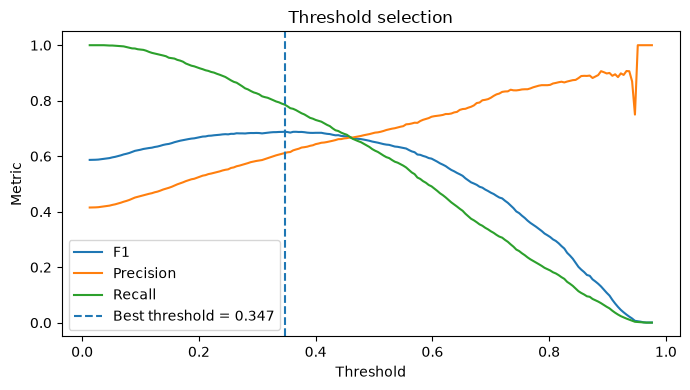

Best threshold: 0.3469
Best F1:        0.6881
Precision:      0.6119
Recall:         0.7861


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [61]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob"
]

train_and_eval_rf(FEATURES)

Train AUROC: 0.9066
Val   AUROC: 0.8750

TRAIN
Short AUROC: 0.9008
Long  AUROC: 0.8630

VALIDATION
Short AUROC: 0.8678
Long  AUROC: 0.8187


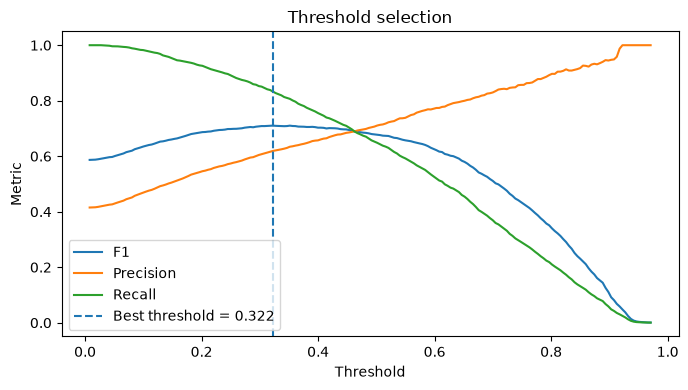

Best threshold: 0.3224
Best F1:        0.7103
Precision:      0.6190
Recall:         0.8331


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [62]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.9120
Val   AUROC: 0.8758

TRAIN
Short AUROC: 0.9048
Long  AUROC: 0.8723

VALIDATION
Short AUROC: 0.8664
Long  AUROC: 0.8211


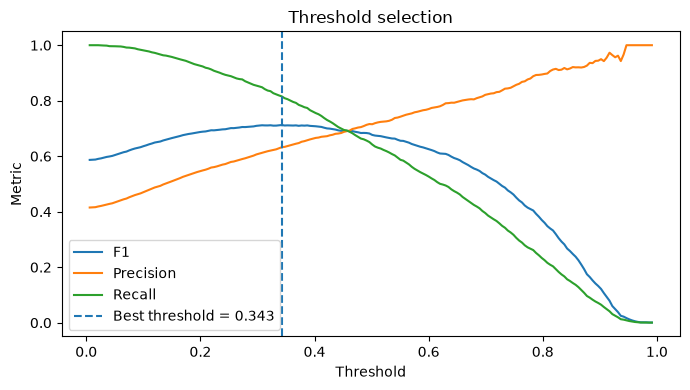

Best threshold: 0.3427
Best F1:        0.7125
Precision:      0.6325
Recall:         0.8155


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [63]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "beam_2_llmlogprob",
    "beam_2_asrlogprob",
    "beam_3_llmlogprob",
    "beam_3_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
train_and_eval_rf(FEATURES)

Train AUROC: 0.9111
Val   AUROC: 0.8760

TRAIN
Short AUROC: 0.9039
Long  AUROC: 0.8706

VALIDATION
Short AUROC: 0.8694
Long  AUROC: 0.8200


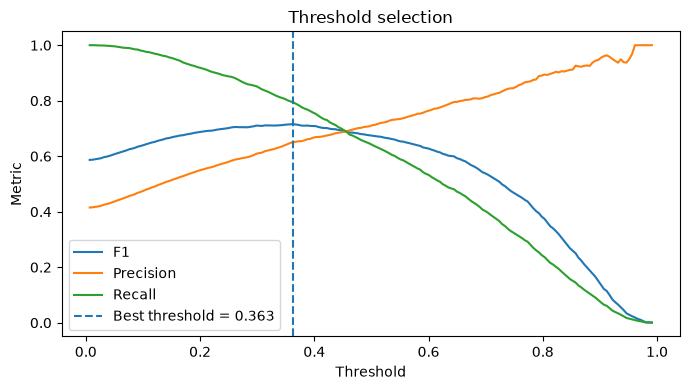

Best threshold: 0.3629
Best F1:        0.7156
Precision:      0.6510
Recall:         0.7945


In [64]:
FEATURES = [
    "num_tokens_text",
    # "highest_score",
    "beam_1_llmlogprob",
    "beam_1_asrlogprob",
    "max_llmlogprobs",
    "min_llmlogprobs",
    "spread_llmlogprobs",
    "max_asrlogprobs",
    "min_asrlogprobs",
    "spread_asrlogprobs",
]
rf = train_and_eval_rf(FEATURES)